# Results & Analysis — Retail OOS Pipeline

Portfolio "proof of work" notebook. Charts here go into the README.

**Sections**

- **A. Dataset overview** — shape, daily revenue over time
- **B. Tier story** — composition + revenue Pareto
- **C. Forecast methodology** — DOW seasonality, trend-factor distribution
- **D. Forecast accuracy** — WAPE histogram, summary, by-tier, worst products
- **E. OOS / business outcomes** — country breakdown, balance colors, reorder Pareto

In [0]:
%run ../config/pipeline_config

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Table references reused across cells.
sdf_bronze   = spark.table(T_BRONZE_SALES)
sdf_history  = spark.table(T_SILVER_HISTORY)
sdf_stats    = spark.table(T_SILVER_AGENT_STATS)
sdf_forecast = spark.table(T_SILVER_FORECAST)
sdf_accuracy = spark.table(T_SILVER_ACCURACY)
sdf_balance  = spark.table(T_SILVER_BALANCE)
sdf_gold     = spark.table(T_GOLD_KPI)

## A. Dataset overview

### A.1 Data shape card

Single-row summary: rows, distinct products, date range, countries, returns share.

In [0]:
shape_row = sdf_bronze.agg(
    F.count(F.lit(1)).alias("rows"),
    F.countDistinct("StockCode").alias("products"),
    F.min("tbl_dt").alias("first_date"),
    F.max("tbl_dt").alias("last_date"),
    F.countDistinct("tbl_dt").alias("distinct_days"),
    F.countDistinct("Country").alias("countries"),
    F.sum((F.col("Quantity") < 0).cast("int")).alias("return_lines"),
).first().asDict()

shape_row["returns_pct"] = round(
    shape_row["return_lines"] / shape_row["rows"], 4
)
pd.DataFrame([shape_row])

,rows,products,first_date,last_date,distinct_days,countries,return_lines,returns_pct
0,535337,4068,2025-04-23,2026-04-29,303,38,10548,0.0197


### A.2 Daily revenue over time

Sum of `daily_sales` across all products per day. Reveals seasonality + any growth/decline trend across the dataset's ~305-day window.

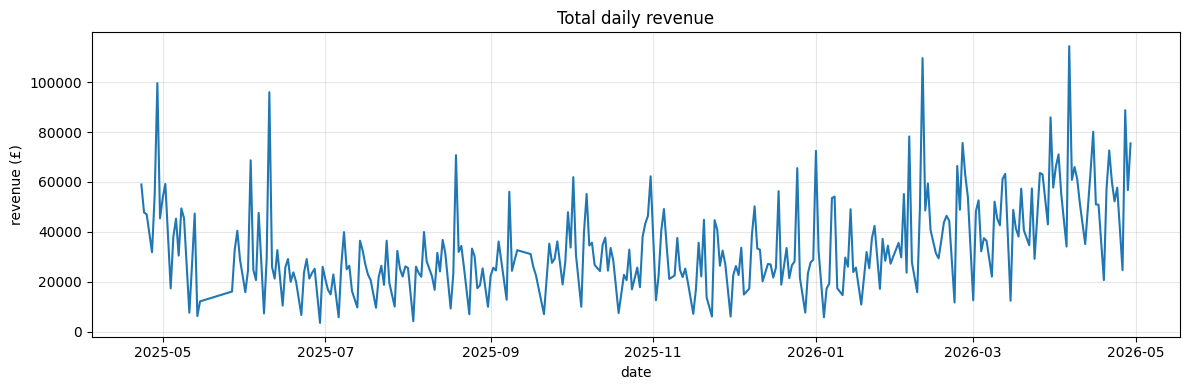

In [0]:
df_daily = (sdf_history
    .groupBy("tbl_dt")
    .agg(F.sum("daily_sales").alias("daily_revenue"))
    .orderBy("tbl_dt")
    .toPandas())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_daily["tbl_dt"], df_daily["daily_revenue"])
ax.set_title("Total daily revenue")
ax.set_xlabel("date")
ax.set_ylabel(f"revenue ({CURRENCY_SYMBOL})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## B. Tier story

### B.1 Tier composition + revenue Pareto

How many products land in each tier, and what % of total revenue each tier accounts for. Classic Pareto: a small set of T1 products typically dominates revenue.

In [0]:
sdf_total = (sdf_history.groupBy("StockCode")
                        .agg(F.sum("daily_sales").alias("total_revenue")))

df_tier = (sdf_stats.select("StockCode", "tier")
    .join(sdf_total, "StockCode", "left")
    .groupBy("tier")
    .agg(F.count(F.lit(1)).alias("n_products"),
         F.sum(F.coalesce(F.col("total_revenue"), F.lit(0.0))).alias("total_revenue"))
    .orderBy("tier")
    .toPandas())

df_tier["pct_products"] = df_tier["n_products"]    / df_tier["n_products"].sum()
df_tier["pct_revenue"]  = df_tier["total_revenue"] / df_tier["total_revenue"].sum()
df_tier

,tier,n_products,total_revenue,pct_products,pct_revenue
0,T1,861,7873399.400,0.219643,0.758278
1,T2,2032,2325006.271,0.518367,0.223919
2,T3,1027,184863.273,0.261990,0.017804


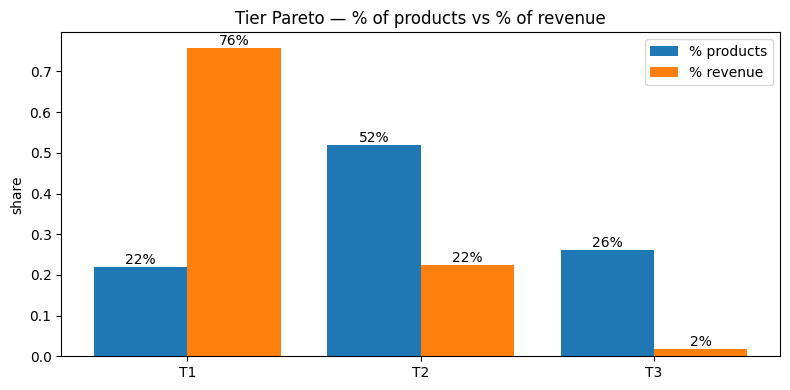

In [0]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(df_tier))
w = 0.4
ax.bar([i - w/2 for i in x], df_tier["pct_products"], width=w, label="% products")
ax.bar([i + w/2 for i in x], df_tier["pct_revenue"],  width=w, label="% revenue")
ax.set_xticks(list(x))
ax.set_xticklabels(df_tier["tier"])
ax.set_ylabel("share")
ax.set_title("Tier Pareto — % of products vs % of revenue")
ax.legend()
for i, (p, r) in enumerate(zip(df_tier["pct_products"], df_tier["pct_revenue"])):
    ax.text(i - w/2, p, f"{p:.0%}", ha="center", va="bottom")
    ax.text(i + w/2, r, f"{r:.0%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## C. Forecast methodology validation

### C.1 DOW seasonality

Total daily sales summed across all products, by day of week. Justifies the DOW-median feature in `silver/04_compute_forecast`. If the bars are flat, DOW isn't doing useful work.

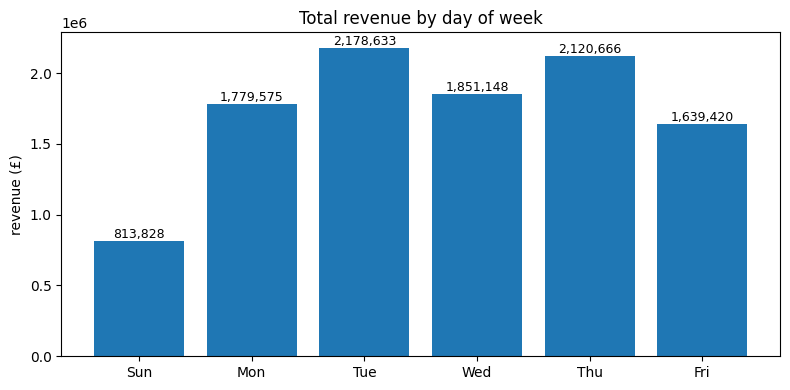

In [0]:
df_dow = (sdf_history
    .withColumn("dow", F.dayofweek("tbl_dt"))                # 1=Sun..7=Sat
    .groupBy("dow")
    .agg(F.sum("daily_sales").alias("total_revenue"))
    .orderBy("dow")
    .toPandas())

day_names = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
df_dow["day"] = df_dow["dow"].apply(lambda d: day_names[int(d) - 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_dow["day"], df_dow["total_revenue"])
ax.set_title("Total revenue by day of week")
ax.set_ylabel(f"revenue ({CURRENCY_SYMBOL})")
for i, v in enumerate(df_dow["total_revenue"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### C.2 Trend-factor distribution

Histogram of `trend_factor` per product, faceted by tier. Each tier has its own clip range (T1 widest, T3 tightest). A spike at exactly 1.0 = products that fell back to no-trend (sparse-data NULL slope or clipped to identity).

`trend_factor` is the same across the 7 DOW rows for a given product, so we dedupe to one row per `StockCode`.

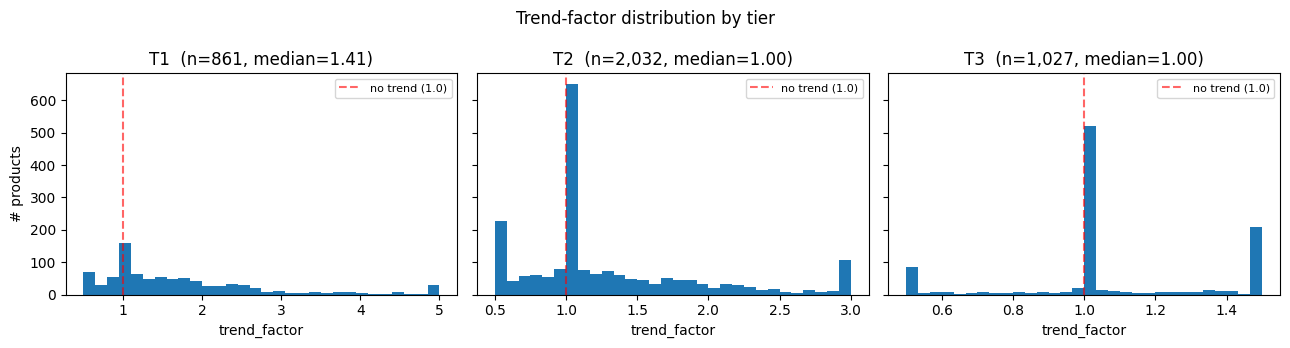

In [0]:
df_trend = (sdf_forecast
    .select("StockCode", "tier", "trend_factor")
    .dropDuplicates(["StockCode"])
    .toPandas())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, tier in zip(axes, ["T1", "T2", "T3"]):
    sub = df_trend[df_trend["tier"] == tier]["trend_factor"]
    ax.hist(sub, bins=30)
    ax.axvline(1.0, color="red", linestyle="--", alpha=0.6, label="no trend (1.0)")
    ax.set_title(f"{tier}  (n={len(sub):,}, median={sub.median():.2f})")
    ax.set_xlabel("trend_factor")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("# products")
plt.suptitle("Trend-factor distribution by tier")
plt.tight_layout()
plt.show()

## D. Forecast accuracy

### D.1 WAPE histogram across all products

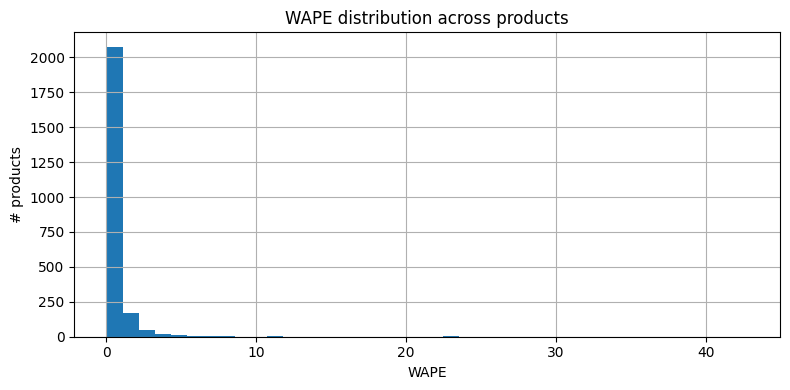

In [0]:
df_acc = sdf_accuracy.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
df_acc["wape"].dropna().hist(bins=40, ax=ax)
ax.set_title("WAPE distribution across products")
ax.set_xlabel("WAPE")
ax.set_ylabel("# products")
plt.tight_layout()
plt.show()

### D.2 WAPE summary — three perspectives

- **Median WAPE** — robust per-product central tendency.
- **Pooled WAPE** — Σ|err| / Σactual; volume-weighted (the inventory KPI).
- **Distribution** — p25 / p50 / p75 + share of products under 50%.

In [0]:
valid       = df_acc.dropna(subset=["wape"])
n_total     = len(df_acc)
n_scored    = len(valid)
n_zero      = n_total - n_scored
median_wape = valid["wape"].median()
pooled_wape = valid["sum_abs_err"].sum() / valid["sum_actual"].sum()
p25, p50, p75 = valid["wape"].quantile([0.25, 0.50, 0.75])
share_lt_50  = (valid["wape"] < 0.5).mean()

summary = pd.DataFrame([{
    "products_scored":   n_scored,
    "products_zero_act": n_zero,
    "median_wape":       round(median_wape, 3),
    "pooled_wape":       round(pooled_wape, 3),
    "p25":               round(p25, 3),
    "p75":               round(p75, 3),
    "share_under_50pct": round(share_lt_50, 3),
}])
summary

,products_scored,products_zero_act,median_wape,pooled_wape,p25,p75,share_under_50pct
0,2343,0,0.673,0.73,0.491,0.858,0.259


### D.3 WAPE by tier

Median + pooled WAPE split by tier. Expect T1 (high-volume) to forecast best; T3 (low-volume / sparse) to forecast worst.

In [0]:
df_wape_tier = (sdf_accuracy
    .join(sdf_stats.select("StockCode", "tier"), "StockCode", "left")
    .filter(F.col("wape").isNotNull())
    .groupBy("tier")
    .agg(
        F.count(F.lit(1)).alias("n_products"),
        F.expr("percentile_approx(wape, 0.5)").alias("median_wape"),
        (F.sum("sum_abs_err") / F.sum("sum_actual")).alias("pooled_wape"),
        F.avg((F.col("wape") < 0.5).cast("int")).alias("share_under_50pct"),
    )
    .orderBy("tier")
    .toPandas())

for col in ["median_wape", "pooled_wape", "share_under_50pct"]:
    df_wape_tier[col] = df_wape_tier[col].round(3)
df_wape_tier

,tier,n_products,median_wape,pooled_wape,share_under_50pct
0,T1,694,0.676,0.732,0.206
1,T2,1237,0.672,0.720,0.270
2,T3,412,0.667,0.730,0.318


### D.4 Worst-forecast products

Top-10 products by WAPE — the honest portfolio piece. Restricted to products with at least 3 holdout days so we're not just picking up products with 1 noisy datapoint.

In [0]:
df_worst = (sdf_accuracy
    .join(sdf_stats.select("StockCode", "tier", "avg_daily_sales"), "StockCode", "left")
    .filter(F.col("wape").isNotNull() & (F.col("test_days") >= 3))
    .orderBy(F.col("wape").desc())
    .limit(10)
    .select("StockCode", "tier", "test_days",
            F.round("wape", 3).alias("wape"),
            F.round("avg_daily_sales", 2).alias("avg_daily_£"),
            F.round("sum_actual", 2).alias("actual_£"),
            F.round("sum_forecast", 2).alias("forecast_£"),
            F.round("bias_correction", 2).alias("bias_corr"))
    .toPandas())
df_worst

,StockCode,tier,test_days,wape,avg_daily_£,actual_£,forecast_£,bias_corr
0,23216,T2,3,8.492,16.53,5.00,47.46,0.5
1,85071D,T3,3,5.906,3.90,1.17,8.08,0.5
2,23306,T1,3,5.763,33.52,7.29,49.30,0.5
3,22541,T3,3,4.609,6.32,3.89,21.82,0.5
4,23121,T2,3,4.600,13.37,4.20,21.84,0.5
5,23006,T3,3,4.018,6.46,1.67,8.38,0.5
6,23360,T1,4,3.744,32.75,19.73,93.60,0.5
7,21125,T2,3,3.661,9.67,7.50,34.96,0.5
8,84987,T2,3,3.500,23.06,8.70,39.15,0.5
9,85177,T2,3,3.443,11.20,5.74,25.50,0.5


## E. OOS / business outcomes

### E.1 OOS rate by country

Top 15 countries by OOS rate, restricted to countries with at least 5 products so a single OOS doesn't dominate.

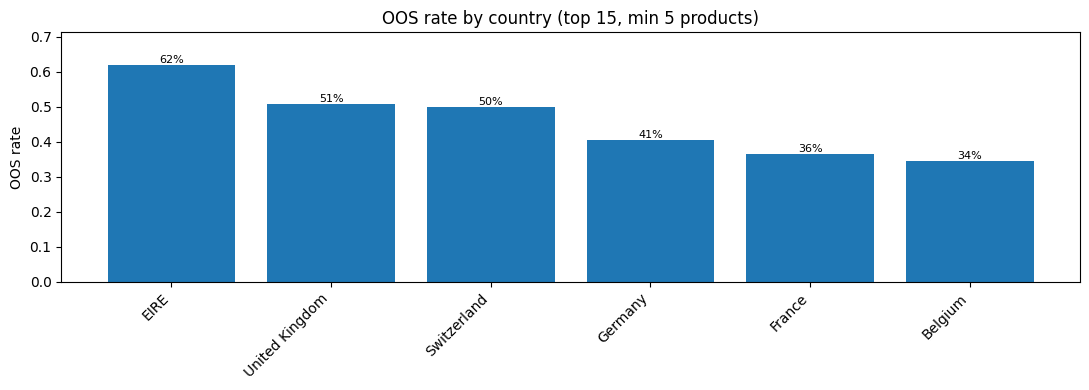

In [0]:
df_country = (sdf_gold
    .filter(F.col("country").isNotNull())
    .groupBy("country")
    .agg(F.count(F.lit(1)).alias("n_products"),
         F.sum(F.col("is_oos").cast("int")).alias("n_oos"))
    .filter(F.col("n_products") >= 5)
    .withColumn("oos_rate", F.col("n_oos") / F.col("n_products"))
    .orderBy(F.col("oos_rate").desc())
    .limit(15)
    .toPandas())

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(df_country["country"], df_country["oos_rate"])
ax.set_title("OOS rate by country (top 15, min 5 products)")
ax.set_ylabel("OOS rate")
ax.set_ylim(0, max(df_country["oos_rate"]) * 1.15)
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(df_country["oos_rate"]):
    ax.text(i, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

### E.2 balance_color breakdown

Distribution of GREEN / AMBER / RED across all products. The at-a-glance status from `gold/07_compute_kpis.py`.

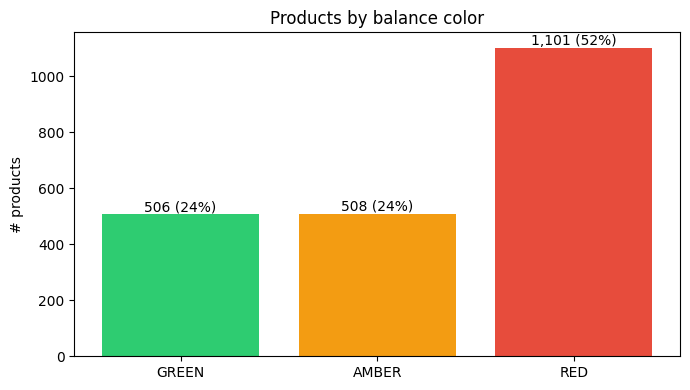

In [0]:
df_color = (sdf_gold
    .groupBy("balance_color")
    .agg(F.count(F.lit(1)).alias("n_products"))
    .toPandas())

color_map = {"GREEN": "#2ecc71", "AMBER": "#f39c12", "RED": "#e74c3c"}
order     = ["GREEN", "AMBER", "RED"]
df_color  = df_color.set_index("balance_color").reindex(order).reset_index()
df_color["share"] = df_color["n_products"] / df_color["n_products"].sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_color["balance_color"], df_color["n_products"],
              color=[color_map[c] for c in df_color["balance_color"]])
ax.set_title("Products by balance color")
ax.set_ylabel("# products")
for i, (n, s) in enumerate(zip(df_color["n_products"], df_color["share"])):
    ax.text(i, n, f"{int(n):,} ({s:.0%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### E.3 Reorder-qty Pareto

Cumulative share of total reorder need vs share of products (sorted desc by `reorder_qty`). The classic 80/20 chart — tells a buyer where to focus first.

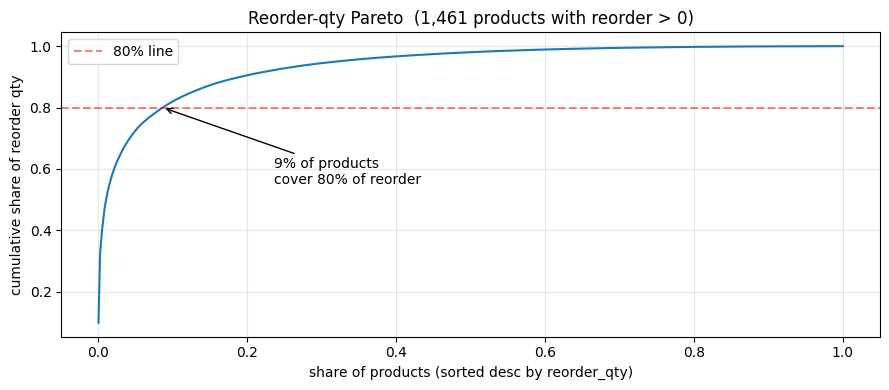

In [0]:
df_reorder = (sdf_gold
    .filter(F.col("reorder_qty") > 0)
    .select("stock_code", "reorder_qty")
    .toPandas()
    .sort_values("reorder_qty", ascending=False)
    .reset_index(drop=True))

if len(df_reorder) == 0:
    print("No products with reorder_qty > 0 — every product has adequate balance.")
else:
    total = df_reorder["reorder_qty"].sum()
    df_reorder["cum_share"]    = df_reorder["reorder_qty"].cumsum() / total
    df_reorder["pct_products"] = (df_reorder.index + 1) / len(df_reorder)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(df_reorder["pct_products"], df_reorder["cum_share"])
    ax.axhline(0.8, color="red", linestyle="--", alpha=0.5, label="80% line")
    ax.set_xlabel("share of products (sorted desc by reorder_qty)")
    ax.set_ylabel("cumulative share of reorder qty")
    ax.set_title(f"Reorder-qty Pareto  ({len(df_reorder):,} products with reorder > 0)")
    ax.legend()
    ax.grid(alpha=0.3)

    # Annotate where we cross 80%.
    cross = df_reorder[df_reorder["cum_share"] >= 0.8].iloc[0]
    ax.annotate(f"{cross['pct_products']:.0%} of products\ncover 80% of reorder",
                xy=(cross["pct_products"], 0.8),
                xytext=(cross["pct_products"] + 0.15, 0.55),
                arrowprops=dict(arrowstyle="->"))
    plt.tight_layout()
    plt.show()